In [1]:
import sys
sys.path.append('../')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
losses = []
with open('../train.log', 'r') as f:
    line_tracker = 1
    for line in f:
        if line_tracker <= 50:
            loss = float(line.strip().split('=')[-1])
            losses.append(loss)
            line_tracker += 1

In [3]:
df = pd.DataFrame(columns=['step', 'loss'])
df.step = range(len(losses))
df.loss = losses

In [4]:
df

,step,loss
0,0,-36165.8575
1,1,-41369.2860
2,2,-46114.4067
3,3,-49437.7144
4,4,-51731.2078
5,5,-53216.8333
6,6,-54481.2963
7,7,-55343.3291
8,8,-56485.3811
9,9,-57657.2588


In [5]:
df.to_csv('/scr/yren/glow1-log.csv', index=False)

Text(0.5, 1.0, 'Training Loss')

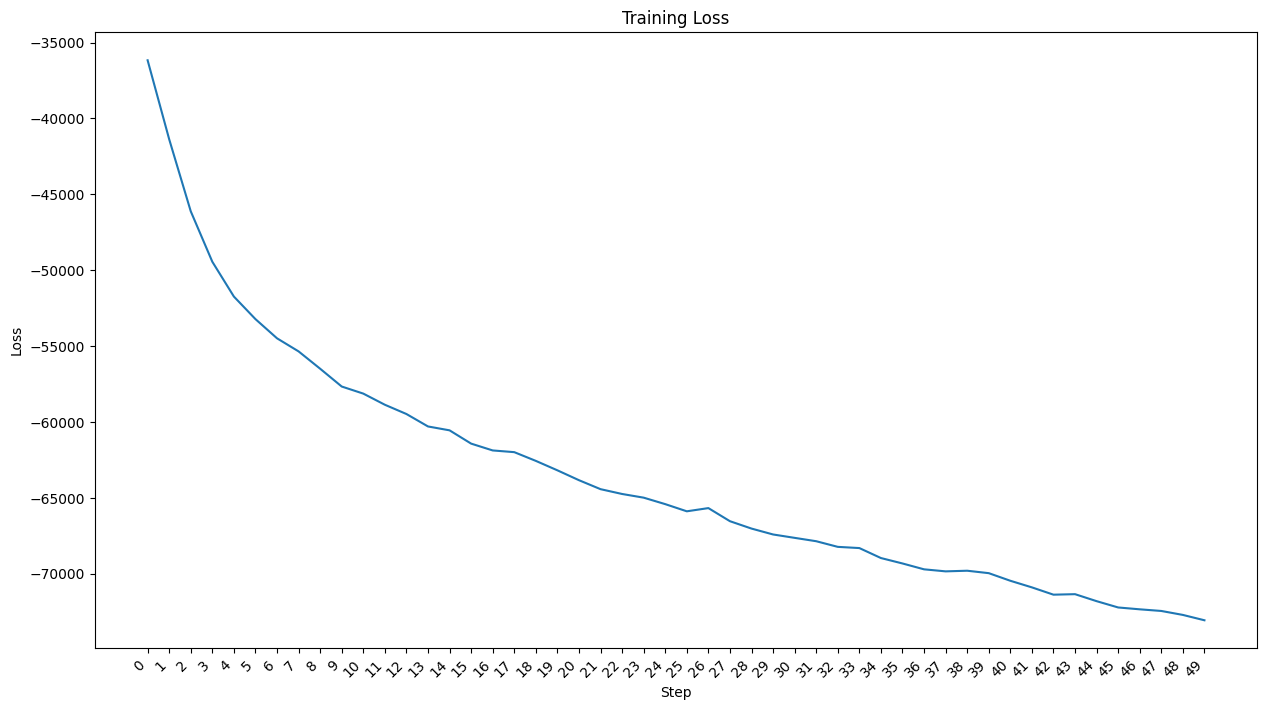

In [6]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(df['step'], df['loss'])
ax.set_xticks(range(50))
ax.set_xticklabels(range(50), rotation=45, ha='right')

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')

# Load pre-trained model

In [7]:
from train import load_glow_models

In [11]:
path = '../checkpoints'
flow1, llm1 = load_glow_models(path=path,
                               flow_model_name='glow-ckpt-1.pth',
                               llm_model_name='llm-ckpt-1.pth',
                               cond_dim=256, n_levels=4, n_steps=8)

flow2, llm2 = load_glow_models(path=path,
                               flow_model_name='glow-ckpt-2.pth',
                               llm_model_name='llm-ckpt-2.pth',
                               cond_dim=256, n_levels=4, n_steps=12)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded Glow weights.
Loaded LLM weights.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded Glow weights.
Loaded LLM weights.


In [12]:
import torch

In [13]:
import requests
from PIL import Image
from io import BytesIO

def _fetch_image(url):
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content))
    if hasattr(img, 'n_frames') and img.n_frames > 1:  # handle GIFs
        img.seek(0)
    return img.convert("RGB")

In [14]:
nasa = pd.read_csv('../Data/apod_clean_urls.csv')

In [15]:
import skimage

- Model 1

In [20]:
prompts = [nasa.loc[i, 'explanation'] for i in range(10)]
ims = []
orig_ims = []
for i in range(10):
    orig = skimage.io.imread(f'../images/{i}.png')
    orig_ims.append(orig)

with torch.no_grad():
    for prompt in prompts:
        context = llm1(prompt)
        gen_im = flow1.sample(1, context=context)
        ims.append(gen_im[0, 0])

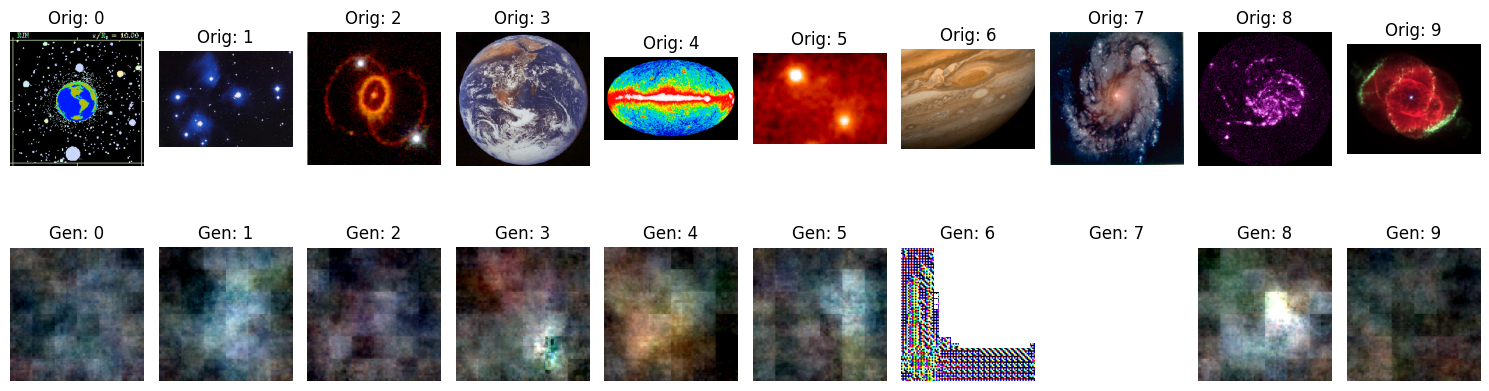

In [21]:
figs, axes = plt.subplots(2, 10, figsize=(15, 5))

for i in range(10):
    # original images
    axes[0, i].imshow(orig_ims[i])
    axes[0, i].set_title(f"Orig: {i}")
    axes[0, i].axis('off')

    # generated samples
    axes[1, i].imshow(ims[i].detach().permute(1, 2, 0).cpu())
    axes[1, i].set_title(f"Gen: {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

- Model 2

In [18]:
prompts = [nasa.loc[i, 'explanation'] for i in range(10)]
ims = []
orig_ims = []
for i in range(10):
    orig = skimage.io.imread(f'../images/{i}.png')
    orig_ims.append(orig)

with torch.no_grad():
    for prompt in prompts:
        context = llm2(prompt)
        gen_im = flow2.sample(1, context=context)
        ims.append(gen_im[0, 0])

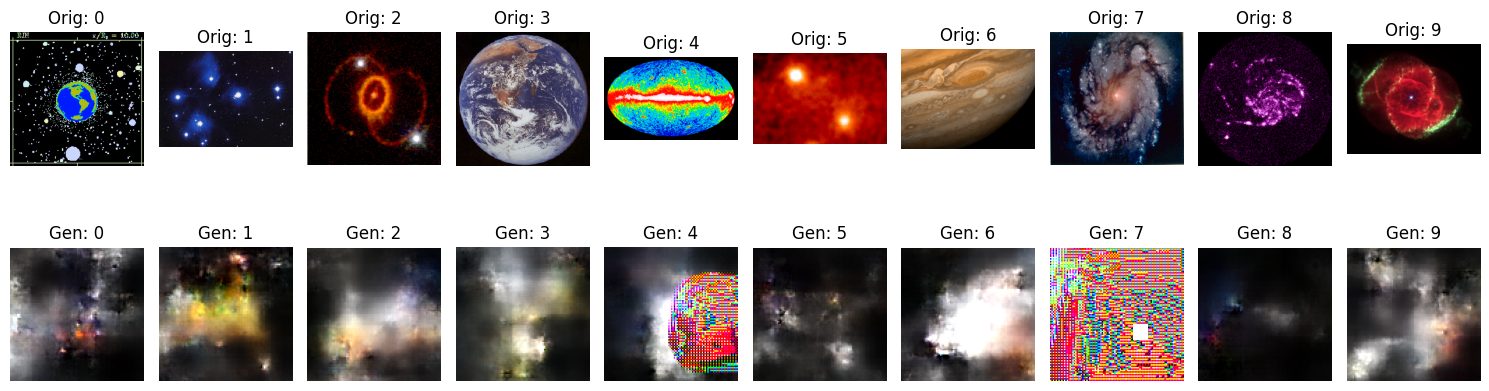

In [19]:
figs, axes = plt.subplots(2, 10, figsize=(15, 5))

for i in range(10):
    # original images
    axes[0, i].imshow(orig_ims[i])
    axes[0, i].set_title(f"Orig: {i}")
    axes[0, i].axis('off')

    # generated samples
    axes[1, i].imshow(ims[i].detach().permute(1, 2, 0).cpu())
    axes[1, i].set_title(f"Gen: {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()